# Data Preparation

In [7]:
import torchvision
import torch 
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt 
import numpy as np 

In [21]:
# Point to dataset paths

train_dataset_path = '../dataset/processed/train'
test_dataset_path = '../dataset/processed/test'
val_dataset_path = '../dataset/processed/val'

In [22]:
import os
print(os.path.exists(train_dataset_path)) # Returns True if file exists
print(os.path.exists(test_dataset_path)) 
print(os.path.exists(val_dataset_path))

True
True
True


In [23]:
mean=[0.485, 0.456, 0.406]
std=[0.229, 0.224, 0.225]

# Preprocessing pipeline for training data
train_transforms = transforms.Compose([
    transforms.Resize((640, 640)), # Transform and resize images
    transforms.RandomHorizontalFlip(), # Random flips
    transforms.RandomRotation(15),     # Rotate +/- 15 degrees
    transforms.ToTensor(),             # Convert to tensor
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # MIGHT REMOVE LATER, adjust brightness/contrast
    transforms.Normalize(torch.Tensor(mean), torch.Tensor(std)) # Normalise
])

# Preprocessing pipeline for validation and test data
val_test_transforms = transforms.Compose([
    transforms.Resize((640, 640)),     # Transform and resize images
    transforms.ToTensor(),             # Convert to tensor
    transforms.Normalize(torch.Tensor(mean), torch.Tensor(std)) # Normalise
])


In [24]:
# Create datasets
train_dataset = torchvision.datasets.ImageFolder(root=train_dataset_path, transform=train_transforms)
val_dataset = torchvision.datasets.ImageFolder(root=val_dataset_path, transform=val_test_transforms)
test_dataset = torchvision.datasets.ImageFolder(root=test_dataset_path, transform=val_test_transforms)

In [ ]:
# Shows 6 random transformed images from a dataset

def show_transformed_images(dataset):
    loader = torch.utils.data.DataLoader(dataset, batch_size=6, shuffle=True)
    batch = next(iter(loader))
    images, labels = batch

    grid = torchvision.utils.make_grid(images, nrow=3)
    plt.Figure(figsize=(10,10))
    plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
    print('Labels:', labels)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


Labels: tensor([0, 3, 1, 2, 1, 2])


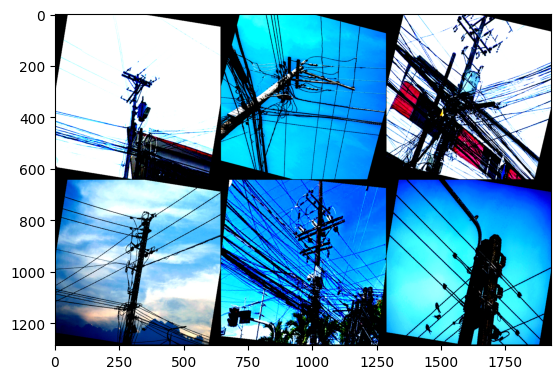

In [28]:
show_transformed_images(train_dataset)

In [ ]:
# Load datasets into dataloaders

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)